# <font color="brown">Customer Segmentation Case Study </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

A retail bank wants to move beyond one-size-fits-all marketing and start treating different kinds of customers differently, who to cross-sell additional products to, who is at risk of quietly leaving, and who is a high-value relationship worth protecting. Right now, the bank has no formal segmentation, just a single undifferentiated customer base. The Head of Retail Banking has asked the analytics team to find natural groupings in the customer base using their account and behavioral data, so different teams (marketing, retention, relationship management) can target each group appropriately.

### <font color="blue"> Objective

As the analyst on this project, you have been asked to segment the bank's customers based on their account and behavioral data. The key questions that need to be answered are:
- How many meaningfully different types (clusters/segments) of customers are there?
- How do these segments differ from each other?
- What should the bank actually *do* differently for each segment?

### <font color="blue"> Data Dictionary

- **Customer_ID**: Unique customer identifier
- **Age**: Customer's age
- **Tenure_Years**: Years the customer has held an account with the bank
- **Balance**: Current account balance
- **Avg_Monthly_Balance**: Average balance held over the past year
- **Num_Products**: Number of bank products held (savings, card, loan, investment, insurance)
- **Transactions_Per_Month**: Average number of transactions per month
- **Avg_Transaction_Value**: Average value per transaction
- **Digital_Engagement_Score**: Mobile/online banking usage frequency (0-100)
- **Credit_Utilization**: % of available credit currently in use
- **Total_Deposits_YTD**: Total money deposited, year to date
- **Total_Withdrawals_YTD**: Total money withdrawn, year to date

## <font color="brown"> Importing Necessary Libraries

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

%matplotlib inline

## <font color="brown"> Reading the Dataset

In [5]:
# loading the dataset
data = pd.read_csv("customer_segmentation.csv")

## <font color="brown"> Overview of the Dataset

### <font color="blue"> Checking the Shape of the Dataset

In [8]:
data.shape

(20000, 12)

* The dataset has 20,000 rows and 12 columns.

### <font color="blue"> Displaying a Few Rows of the Dataset

In [11]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)

,Customer_ID,Age,Tenure_Years,Balance,Avg_Monthly_Balance,Num_Products,Transactions_Per_Month,Avg_Transaction_Value,Digital_Engagement_Score,Credit_Utilization,Total_Deposits_YTD,Total_Withdrawals_YTD
11456,511457,55,3.4,464.82,436.90,1,4.7,38.40,8.9,100.0,890.03,1429.93
16528,516529,36,4.6,7570.81,6813.47,2,11.3,164.55,43.1,25.8,11876.84,11972.96
3253,503254,29,8.8,5161.53,4221.44,3,16.6,10.64,14.2,16.7,1114.69,998.22
18614,518615,27,1.2,0.00,0.00,1,26.3,13.65,83.8,60.9,2554.54,1735.78
1544,501545,70,18.7,28164.88,28789.82,3,10.2,300.78,12.3,15.7,17985.83,12990.94
12568,512569,71,11.7,1148.85,1195.10,2,5.0,73.83,28.2,79.8,3342.87,2242.55
15497,515498,32,0.0,0.00,0.00,2,13.0,99.44,93.2,0.7,7312.77,7490.50
13987,513988,28,0.7,939.96,789.90,2,32.7,47.49,97.0,44.0,12352.19,8935.40
9598,509599,24,2.9,3201.18,2387.21,2,26.8,108.20,96.4,32.4,13538.91,16702.87
6668,506669,27,0.0,157.19,172.47,1,7.9,63.12,34.6,29.6,4306.68,3166.71


### <font color="blue"> Creating a Copy of the Original Data

In [13]:
# copying the data to another variable to avoid any changes to the original data
df = data.copy()

### <font color="blue"> Checking the Data Types of the Columns

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               20000 non-null  int64  
 1   Age                       20000 non-null  int64  
 2   Tenure_Years              20000 non-null  float64
 3   Balance                   20000 non-null  float64
 4   Avg_Monthly_Balance       20000 non-null  float64
 5   Num_Products              20000 non-null  int64  
 6   Transactions_Per_Month    20000 non-null  float64
 7   Avg_Transaction_Value     20000 non-null  float64
 8   Digital_Engagement_Score  20000 non-null  float64
 9   Credit_Utilization        20000 non-null  float64
 10  Total_Deposits_YTD        20000 non-null  float64
 11  Total_Withdrawals_YTD     20000 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 1.8 MB


**Observations**

- `Customer_ID` is an identifier and carries no behavioral information, it will be set aside before clustering.
- Every other column is numeric, which is exactly what K-Means needs, it works on Euclidean distance, so it can only operate on numbers, not categories.

### <font color="blue"> Statistical Summary of the Dataset

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_ID,20000.0,510000.500000,5773.647028,500001.0,505000.7500,510000.500,515000.2500,520000.00
Age,20000.0,41.233550,13.966877,18.0,30.0000,40.000,50.0000,85.00
Tenure_Years,20000.0,7.926490,7.214837,0.0,2.8000,6.000,10.0000,40.00
Balance,20000.0,6552.053723,7220.891681,0.0,1330.6550,3888.045,8834.8050,47571.07
Avg_Monthly_Balance,20000.0,6017.323362,6721.355480,0.0,1208.3500,3528.890,8131.9975,49451.42
Num_Products,20000.0,2.594300,1.524311,1.0,1.0000,2.000,3.0000,8.00
Transactions_Per_Month,20000.0,15.505865,10.061364,0.0,7.1000,13.900,21.9000,54.50
Avg_Transaction_Value,20000.0,141.192072,112.823815,5.0,64.4225,110.310,183.7225,824.20
Digital_Engagement_Score,20000.0,47.096590,28.507383,0.0,21.6000,46.300,71.7000,100.00
Credit_Utilization,20000.0,40.793790,23.380779,0.0,23.4000,37.800,55.4000,100.00


**Observations**

- The features are on very different scales, `Balance` runs into the thousands while `Digital_Engagement_Score` is bounded 0-100 and `Num_Products` only ranges 1-8. This confirms we will need to scale everything before clustering, otherwise `Balance` alone would dominate every distance calculation.
- `Credit_Utilization` and `Digital_Engagement_Score` both range roughly 0-100, but the rest vary widely in spread.

### <font color="blue"> Checking for Missing Values

In [21]:
# checking for missing values
df.isna().sum()

Customer_ID                 0
Age                         0
Tenure_Years                0
Balance                     0
Avg_Monthly_Balance         0
Num_Products                0
Transactions_Per_Month      0
Avg_Transaction_Value       0
Digital_Engagement_Score    0
Credit_Utilization          0
Total_Deposits_YTD          0
Total_Withdrawals_YTD       0
dtype: int64

- There are no missing values in the data.

### <font color="blue"> Checking for Duplicates

In [24]:
df.duplicated().sum()

0

- There are no duplicate rows in the data.

## <font color="brown"> Exploratory Data Analysis

### <font color="blue"> Univariate Analysis

In [28]:
# function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize=(12, 6), bins="auto"):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2, bins=bins, color="skyblue")
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")
    plt.suptitle(feature)
    plt.show()

In [29]:
num_col = [c for c in df.columns if c != "Customer_ID"]
num_col

['Age',
 'Tenure_Years',
 'Balance',
 'Avg_Monthly_Balance',
 'Num_Products',
 'Transactions_Per_Month',
 'Avg_Transaction_Value',
 'Digital_Engagement_Score',
 'Credit_Utilization',
 'Total_Deposits_YTD',
 'Total_Withdrawals_YTD']

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


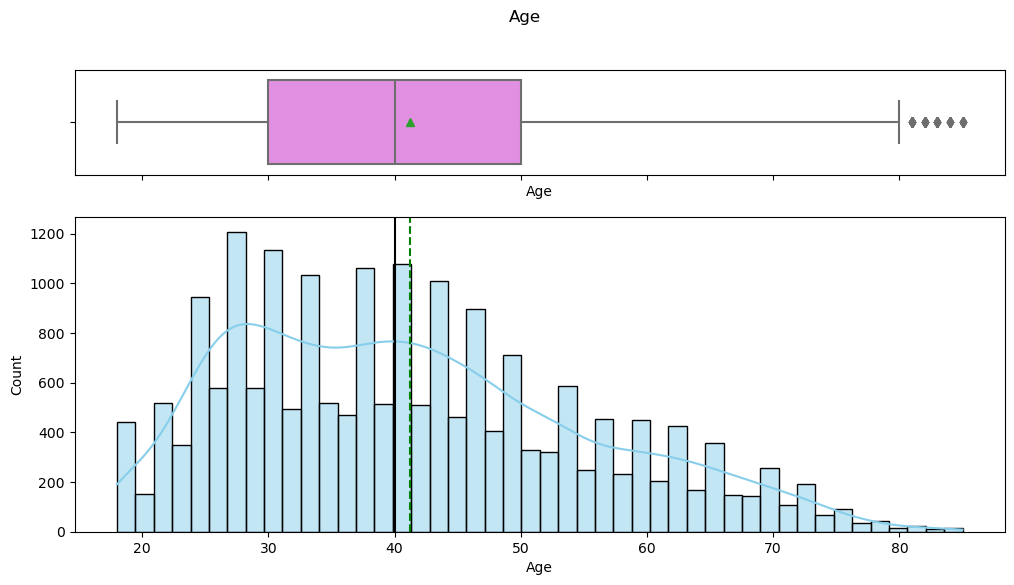

In [30]:
histogram_boxplot(df, "Age")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


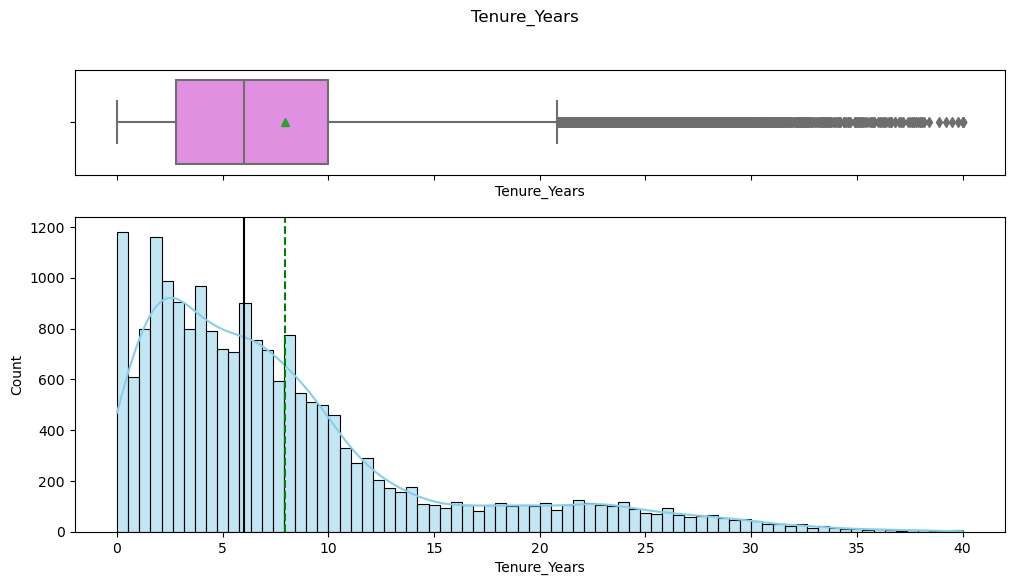

In [31]:
histogram_boxplot(df, "Tenure_Years")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


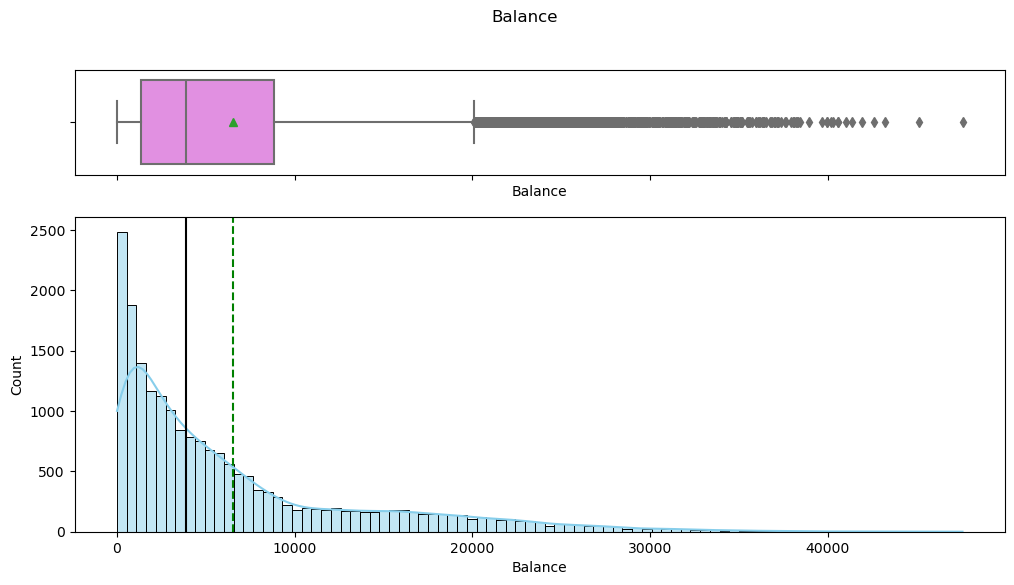

In [32]:
histogram_boxplot(df, "Balance")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


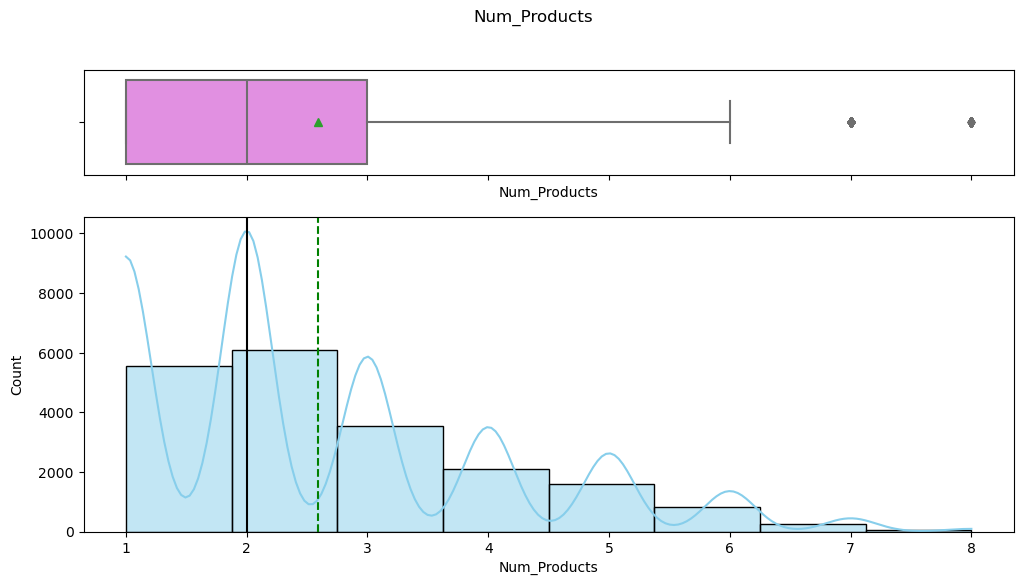

In [33]:
histogram_boxplot(df, "Num_Products", bins=8)

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


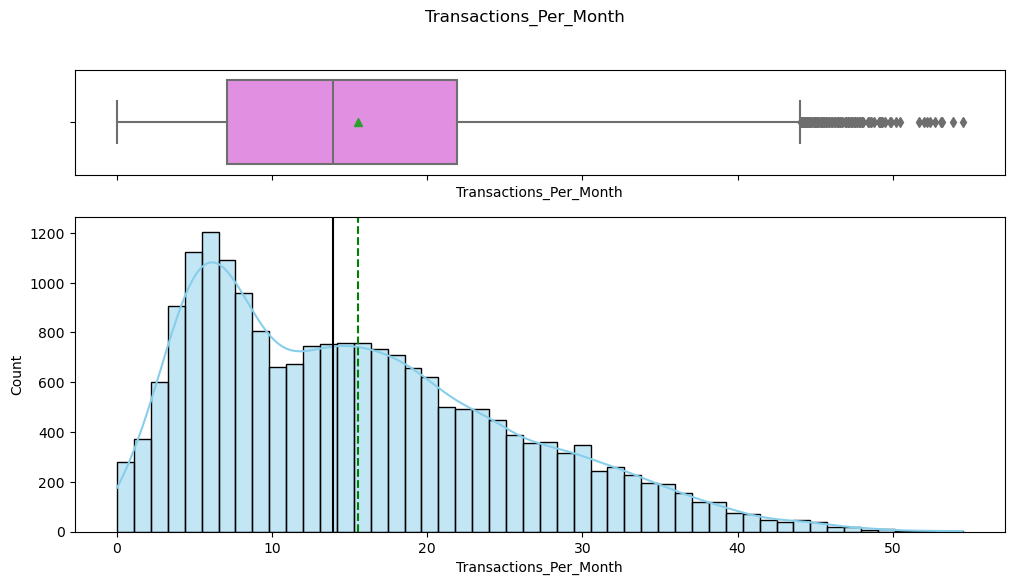

In [34]:
histogram_boxplot(df, "Transactions_Per_Month")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


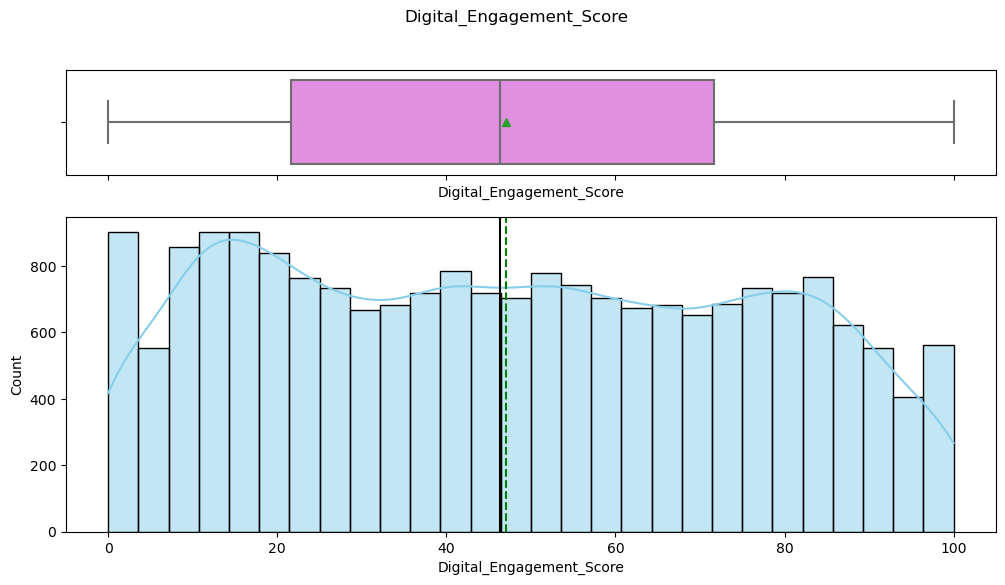

In [35]:
histogram_boxplot(df, "Digital_Engagement_Score")

C:\Users\Admin\anaconda3.2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


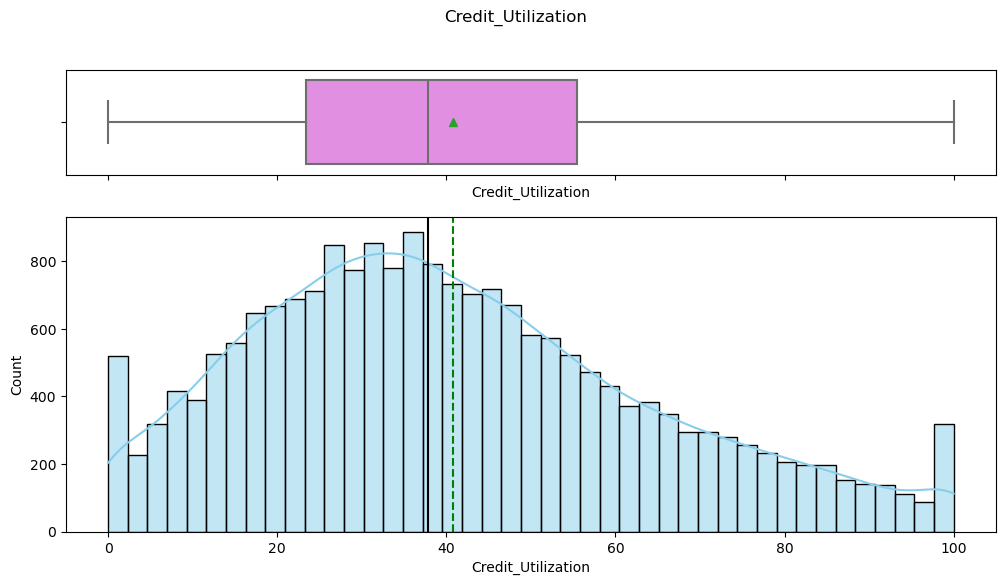

In [36]:
histogram_boxplot(df, "Credit_Utilization")

**Observations**

- `Balance`, `Avg_Monthly_Balance`, and the YTD deposit/withdrawal columns are all right-skewed with a long tail, most customers keep modest balances, with a smaller group holding much larger ones.
- `Digital_Engagement_Score` looks close to bimodal, a hint that there may be genuinely distinct "high digital" and "low digital" groups of customers rather than one smooth spread.
- `Credit_Utilization` also shows more spread than a single bell curve would suggest, again consistent with there being more than one underlying customer type.

### <font color="blue"> Bivariate Analysis

#### Let's check the correlations between features

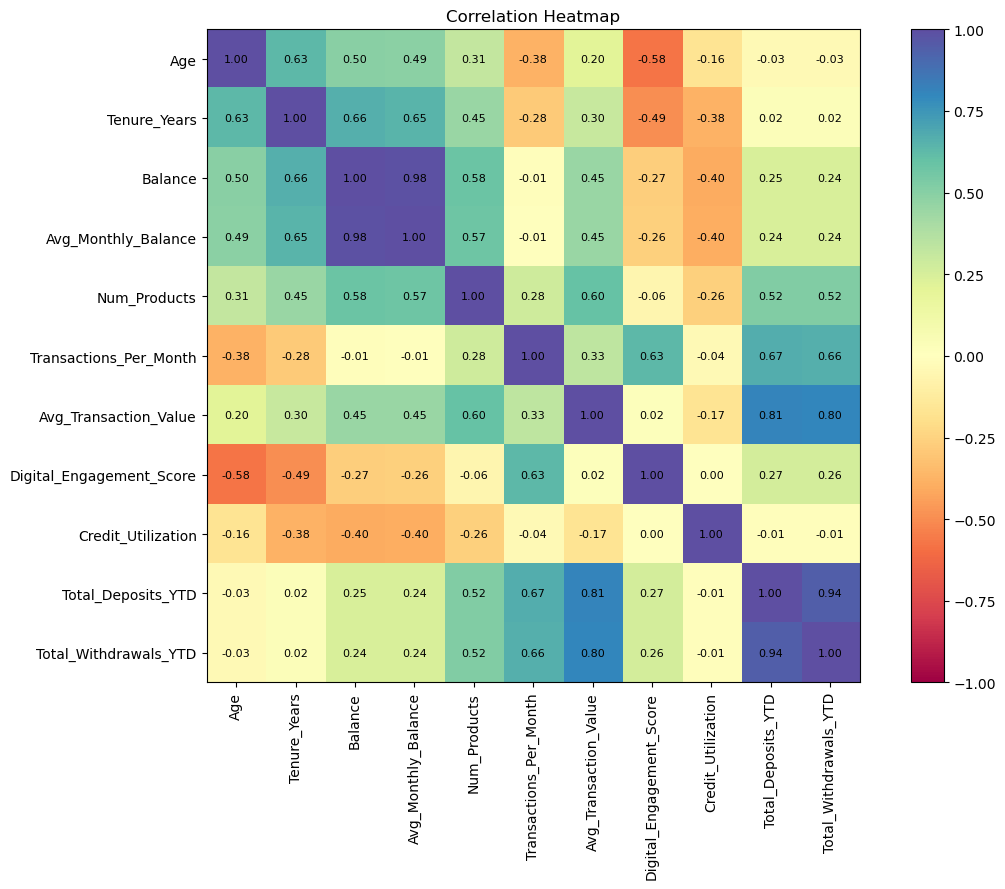

In [40]:
corr_matrix = df[num_col].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_matrix, cmap='Spectral', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

# Annotating each cell manually so every value reliably shows up
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations**

- `Total_Deposits_YTD` and `Total_Withdrawals_YTD` are strongly correlated with each other and with `Transactions_Per_Month` and `Avg_Transaction_Value`, which makes sense, they are all different views of the same underlying "how active is this customer" behaviour.
- `Balance` and `Avg_Monthly_Balance` are, unsurprisingly, almost perfectly correlated.
- `Digital_Engagement_Score` is only weakly correlated with the balance/activity features, suggesting it captures a genuinely different dimension of customer behaviour, not just a proxy for how much money someone has.

## <font color="brown"> Data Preprocessing

K-Means measures how far apart customers are using Euclidean distance, so before clustering we need to (a) set aside `Customer_ID`, which is just a label, not a behavioral feature, and (b) scale every remaining feature so that one large-range column like `Balance` doesn't dominate the distance calculation just because of its units.

In [44]:
# Scaling the data before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [45]:
# Creating a dataframe from the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)
subset_scaled_df.head()

,Age,Tenure_Years,Balance,Avg_Monthly_Balance,Num_Products,Transactions_Per_Month,Avg_Transaction_Value,Digital_Engagement_Score,Credit_Utilization,Total_Deposits_YTD,Total_Withdrawals_YTD
0,0.699275,0.231960,-0.204030,-0.145461,-0.389891,-0.676453,-0.331606,0.312327,-0.217868,-0.393745,-0.427237
1,-1.305518,-0.696705,-0.854278,-0.847238,-1.045941,0.556016,-0.888860,1.469951,-0.855159,-0.448816,-0.435431
2,1.988071,2.699160,1.885760,0.834310,0.266160,-0.895116,-0.104520,-1.122425,-0.915039,-0.454304,-0.515104
3,-0.159922,-0.128418,0.116091,0.024101,-0.389891,-0.298761,-0.917401,-0.041976,-1.004859,-0.550008,-0.571512
4,-0.303121,-0.613541,-0.907397,-0.895277,0.266160,-0.358396,0.487480,1.466443,-0.260639,0.142588,-0.177531


## <font color="brown"> K-Means Clustering

### <font color="blue"> Finding the Appropriate Number of Clusters: Elbow Method

Number of Clusters: 1 	Average Distortion: 2.9944837202262096
Number of Clusters: 2 	Average Distortion: 2.5037708276481556
Number of Clusters: 3 	Average Distortion: 2.1464504484666045
Number of Clusters: 4 	Average Distortion: 1.9123975012903796
Number of Clusters: 5 	Average Distortion: 1.739917295560582
Number of Clusters: 6 	Average Distortion: 1.6785770218226572
Number of Clusters: 7 	Average Distortion: 1.6297013949854917
Number of Clusters: 8 	Average Distortion: 1.6059023947225166


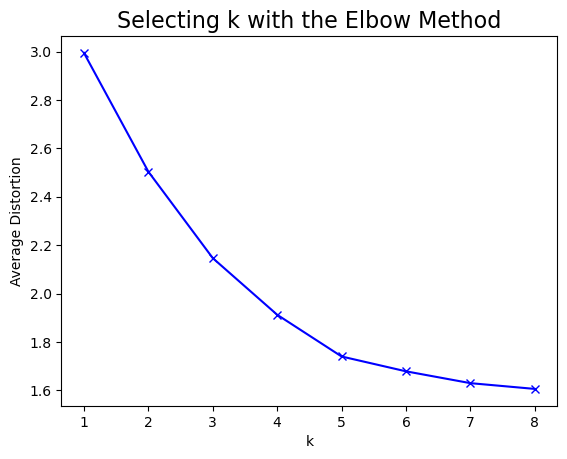

In [48]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1, n_init=10)
    model.fit(subset_scaled_df)
    distortion = (
        sum(np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1))
        / subset_scaled_df.shape[0]
    )
    meanDistortions.append(distortion)
    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=16)
plt.show()

**The distortion drops sharply up to about k=4-5, and flattens out noticeably from there. The elbow points to somewhere around 4 or 5 clusters.**

### <font color="blue"> Let's Check the Silhouette Scores

For n_clusters = 2, silhouette score is 0.4039
For n_clusters = 3, silhouette score is 0.4530
For n_clusters = 4, silhouette score is 0.3224
For n_clusters = 5, silhouette score is 0.2976
For n_clusters = 6, silhouette score is 0.2912
For n_clusters = 7, silhouette score is 0.2695
For n_clusters = 8, silhouette score is 0.2640


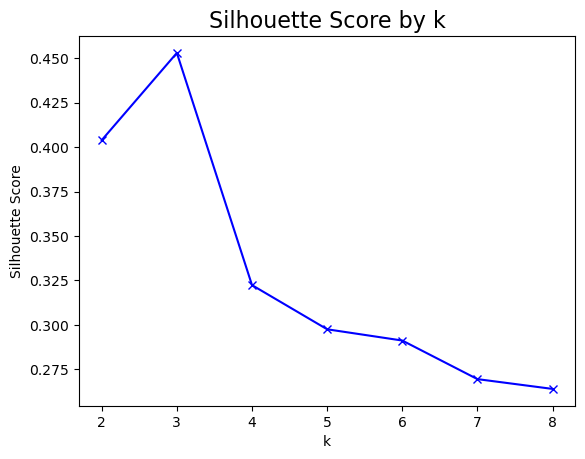

In [51]:
sil_score = []
cluster_list = list(range(2, 9))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init=10)
    preds = clusterer.fit_predict(subset_scaled_df)
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {:.4f}".format(n_clusters, score))

plt.plot(cluster_list, sil_score, "bx-")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k", fontsize=16)
plt.show()

**The silhouette score is mathematically highest at k=3 (≈0.45), with k=5 close behind at ≈0.30. On its own, silhouette score would argue for k=3, but 3 clusters is too coarse for what the bank actually needs, "broad strokes" doesn't tell marketing, retention, and relationship teams enough to act differently. Let's look at a few candidate values of k in more detail before deciding.**

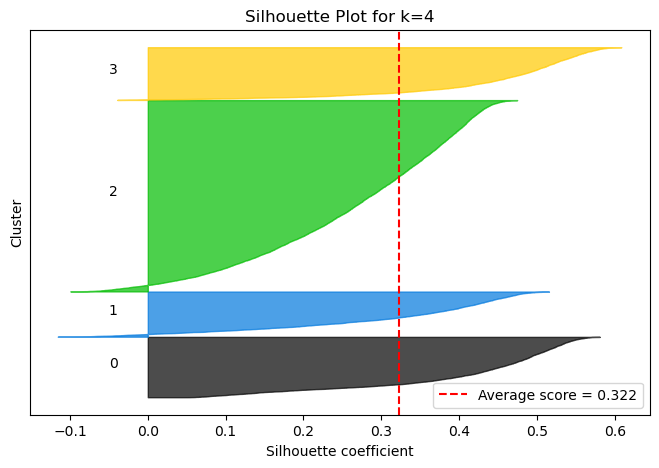

In [53]:
# manual silhouette plot (avoids relying on yellowbrick, whose clustering-estimator
# checks can break across scikit-learn versions)
def plot_silhouette(X, k):
    model = KMeans(n_clusters=k, random_state=1, n_init=10)
    labels = model.fit_predict(X)
    silhouette_vals = silhouette_samples(X, labels)
    avg_score = silhouette_vals.mean()

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10
    for i in range(k):
        cluster_vals = np.sort(silhouette_vals[labels == i])
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        color = plt.cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=avg_score, color="red", linestyle="--", label=f"Average score = {avg_score:.3f}")
    ax.set_title(f"Silhouette Plot for k={k}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    ax.legend(loc="lower right")
    plt.show()


plot_silhouette(subset_scaled_df, 4)

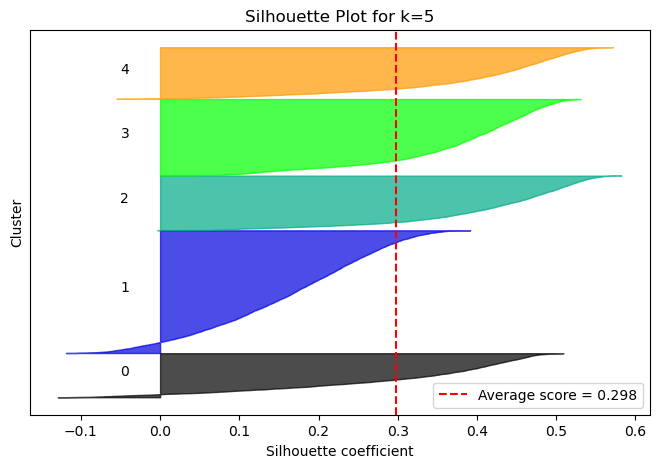

In [54]:
plot_silhouette(subset_scaled_df, 5)

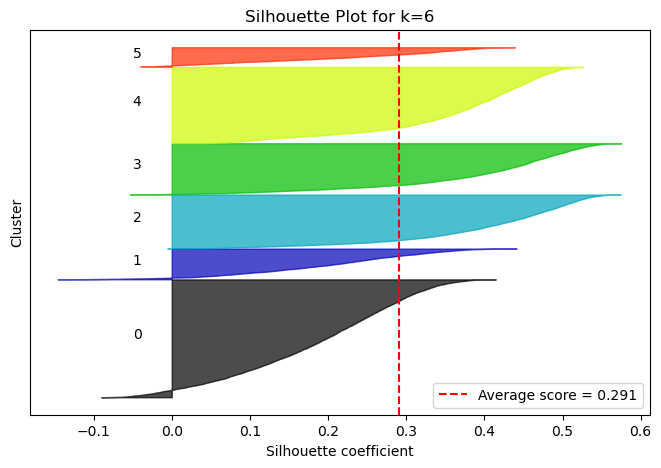

In [55]:
plot_silhouette(subset_scaled_df, 6)

**Here k=5 strikes the best balance for this data:**

- **Still solidly positive:** the average silhouette at k=5 (≈0.30) is comfortably above the commonly used 0.25 threshold for "reasonable, real structure", it is lower than k=3's score, but 3 clusters would blur together customer types the bank needs to treat differently.
- **Well-formed clusters:** most of the silhouette "blades" at k=5 sit past the average line with few negative-silhouette points, meaning customers are, on the whole, closer to their own cluster's centre than to any other cluster.
- **Matches the elbow curve:** k=5 sits right where the elbow curve's steep drop levels off.
- **Interpretability:** five segments is a practical number for the bank's teams to build distinct playbooks around, without being so many that segments become tiny and hard to act on.

### <font color="blue"> Selecting the Final Model

**Let's take k=5 as the final number of clusters, balancing the elbow curve, a solidly positive silhouette score, and business interpretability.**

In [59]:
kmeans = KMeans(n_clusters=5, random_state=1, n_init=10)
kmeans.fit(subset_scaled_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",1
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 11)","[[ 0.

In [60]:
# adding the k-means cluster labels to the original (unscaled) dataframe, for interpretable profiling
df["Segment"] = kmeans.labels_
df["Segment"].value_counts()

Segment
1    7025
3    4376
2    3122
4    2956
0    2521
Name: count, dtype: int64

## <font color="brown"> Cluster Profiling

In [62]:
# Dropping the ID column before profiling, an average Customer_ID is meaningless
cluster_profile = df.drop("Customer_ID", axis=1).groupby("Segment").mean()

In [63]:
cluster_profile["count_in_segment"] = df.groupby("Segment")["Customer_ID"].count().values
cluster_profile

,Age,Tenure_Years,Balance,Avg_Monthly_Balance,Num_Products,Transactions_Per_Month,Avg_Transaction_Value,Digital_Engagement_Score,Credit_Utilization,Total_Deposits_YTD,Total_Withdrawals_YTD,count_in_segment
Segment,,,,,,,,,,,,
0,41.849663,8.900278,12248.831305,11300.358854,5.008330,31.033003,353.420988,64.808251,45.201428,71878.392420,62648.475418,2521
1,38.902918,6.348655,4893.645150,4506.594804,2.395445,14.433851,124.950165,44.098007,34.456128,11746.823277,10177.736414,7025
2,45.025945,5.206022,762.562108,696.223607,1.307495,5.296284,63.301931,21.162940,76.689045,2231.340522,1959.970759,3122
3,27.291819,2.322463,2048.610343,1876.619097,1.606261,21.920475,72.620599,83.326897,40.092596,10449.724664,9070.293163,4376
4,62.880582,22.015088,18416.263802,16851.738430,3.829838,6.098207,182.569638,12.872970,15.223376,7338.306634,6311.773796,2956


In [64]:
# highlighting the highest value in each column, to make each segment's standout traits easy to spot
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Age,Tenure_Years,Balance,Avg_Monthly_Balance,Num_Products,Transactions_Per_Month,Avg_Transaction_Value,Digital_Engagement_Score,Credit_Utilization,Total_Deposits_YTD,Total_Withdrawals_YTD,count_in_segment
Segment,,,,,,,,,,,,
0,41.849663,8.900278,12248.831305,11300.358854,5.008330,31.033003,353.420988,64.808251,45.201428,71878.392420,62648.475418,2521
1,38.902918,6.348655,4893.645150,4506.594804,2.395445,14.433851,124.950165,44.098007,34.456128,11746.823277,10177.736414,7025
2,45.025945,5.206022,762.562108,696.223607,1.307495,5.296284,63.301931,21.162940,76.689045,2231.340522,1959.970759,3122
3,27.291819,2.322463,2048.610343,1876.619097,1.606261,21.920475,72.620599,83.326897,40.092596,10449.724664,9070.293163,4376
4,62.880582,22.015088,18416.263802,16851.738430,3.829838,6.098207,182.569638,12.872970,15.223376,7338.306634,6311.773796,2956


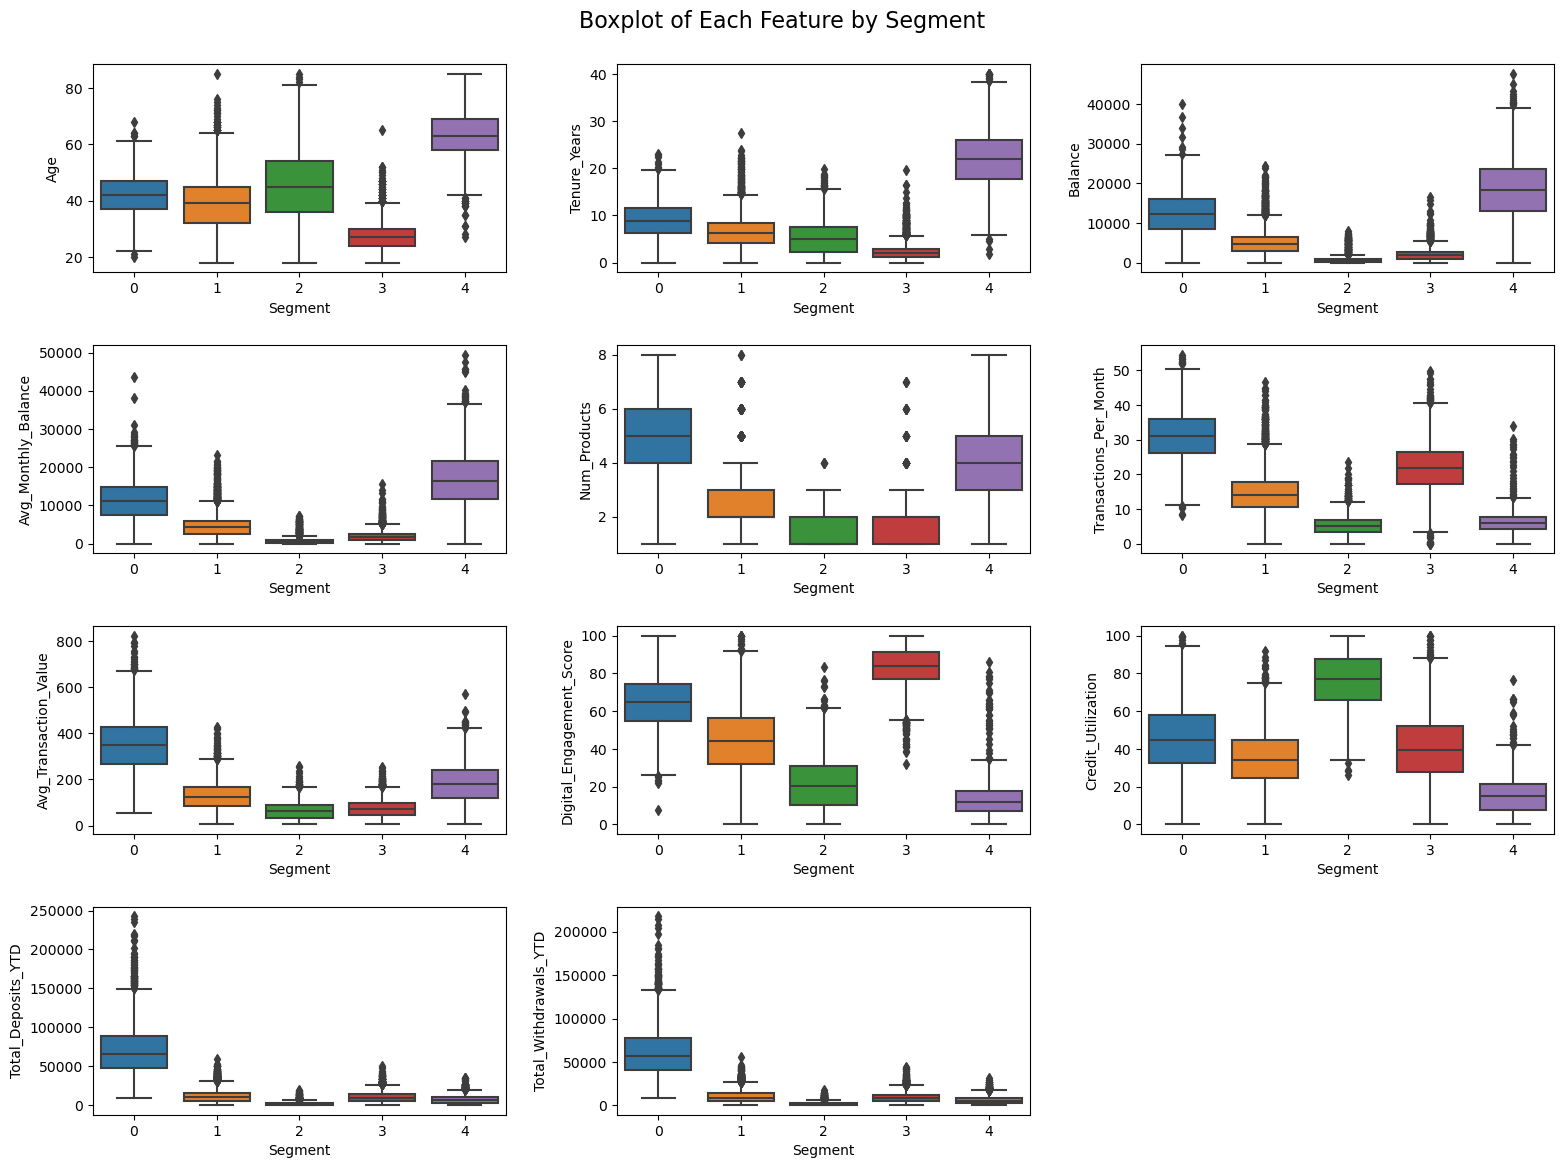

In [65]:
plt.figure(figsize=(16, 12))
plt.suptitle("Boxplot of Each Feature by Segment", fontsize=16)

for i, variable in enumerate(num_col):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(data=df, x="Segment", y=variable)

plt.tight_layout(pad=2.0)
plt.show()

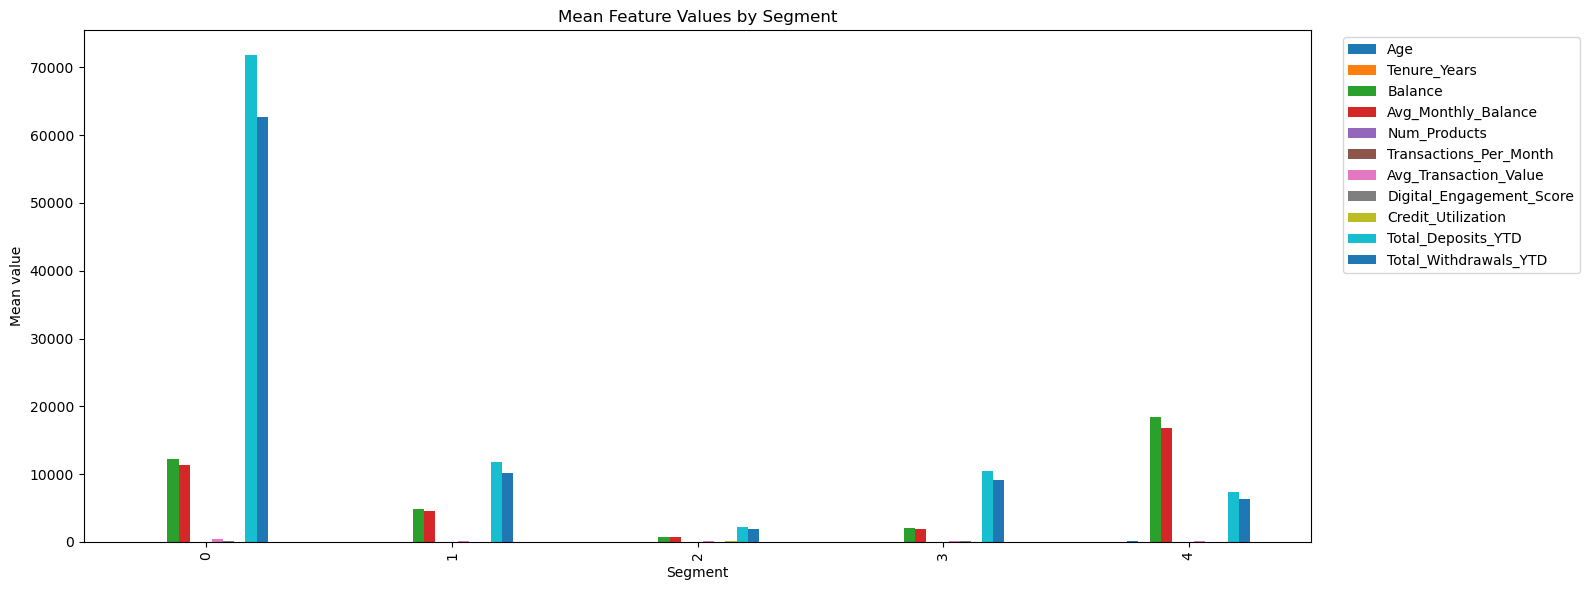

In [66]:
df.drop("Customer_ID", axis=1).groupby("Segment").mean().plot.bar(figsize=(16, 6))
plt.title("Mean Feature Values by Segment")
plt.ylabel("Mean value")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### <font color="blue"> Visualizing the Clusters

Our data has 11 features, more than we can plot directly. To actually *see* how the 5 segments sit relative to each other, we use **PCA** to compress the scaled features down to the 2 directions that capture the most variation, purely for visualization, the clustering itself was already done on all 11 original features.

C:\Users\Admin\anaconda3.2\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Variance captured by these 2 components: 0.6990108998184512


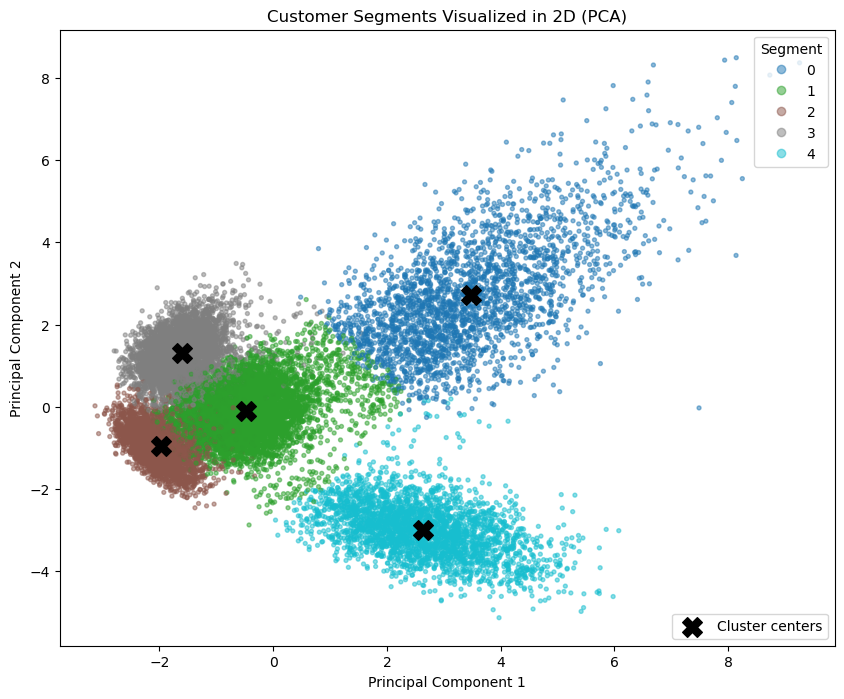

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=1)
pcs = pca.fit_transform(subset_scaled_df)
centers_2d = pca.transform(kmeans.cluster_centers_)

print("Variance captured by these 2 components:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pcs[:, 0], pcs[:, 1], c=df['Segment'], cmap='tab10', s=8, alpha=0.5)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1], c='black', marker='X', s=200, label='Cluster centers')
legend1 = ax.legend(*scatter.legend_elements(), title='Segment', loc='upper right')
ax.add_artist(legend1)
ax.legend(loc='lower right')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('Customer Segments Visualized in 2D (PCA)')
plt.show()

Even after compressing 11 features down to 2, the 5 segments still form clearly separated regions, with the black X marks (cluster centers) sitting right in the middle of each one. Segments 1, 2, and 3 sit closer together than 0 and 4 do, matching what the silhouette analysis already told us: these clusters are real, but not perfectly separated, which is exactly what we'd expect from genuine customer behaviour rather than artificially distinct groups.

### <font color="blue"> Insights

- **Segment 0 — High-Activity Multi-Product:** Comfortably above-average balance and the highest `Num_Products` and `Transactions_Per_Month` of any segment, paired with high `Avg_Transaction_Value` and mid-to-high `Digital_Engagement_Score`. These are the bank's busiest, most fully-engaged customers.

- **Segment 1 — Mainstream:** The largest segment by far, with every metric sitting close to the overall average, moderate balance, moderate activity, moderate digital engagement. This is the bank's typical, broadly satisfied customer.

- **Segment 2 — At-Risk / Declining:** Low balance, low transaction activity, low digital engagement, and by far the highest `Credit_Utilization`. This combination, using a lot of available credit while barely engaging otherwise, is a classic financial-stress signal.

- **Segment 3 — Young Digital Native:** The youngest segment with the shortest `Tenure_Years` by a wide margin, and easily the highest `Digital_Engagement_Score`. Balances are modest, this looks like a segment early in its relationship with the bank, engaging almost entirely through digital channels.

- **Segment 4 — Branch Loyalist:** The oldest segment with by far the longest tenure and the highest balance of any segment, but the lowest `Digital_Engagement_Score` and among the lowest transaction counts. These are long-standing, high-value customers who simply don't interact digitally, likely still relying on branch or phone banking.

## <font color="brown"> Business Insights and Recommendations

- **Segment 4 (Branch Loyalist):** The single most valuable segment by balance held, but the least digitally engaged. The risk here isn't attrition to a competitor, it's simply being under-served by the bank's newer digital products. Assign relationship managers for high-touch, human-first engagement, and introduce digital tools gradually rather than pushing self-service.

- **Segment 0 (High-Activity Multi-Product):** Already the bank's best customers by engagement and product count. Prioritise retention, loyalty perks, premium account tiers, since losing one of these customers costs far more than losing a Mainstream customer.

- **Segment 3 (Young Digital Native):** Low current balance but high digital engagement and early tenure signal long-term potential, not current value. This is the segment to invest in acquiring more deeply: student/first-job product bundles, app-first onboarding, and financial literacy content delivered digitally.

- **Segment 2 (At-Risk/Declining):** High credit utilization with low engagement is an early warning sign worth acting on before it becomes a default or a lost customer. Proactive outreach (not automated marketing) and tailored credit counseling or restructuring offers are appropriate here.

- **Segment 1 (Mainstream):** The largest group, with no strong signal in either direction. This is the segment to run standard, broad-based campaigns on (the term deposit campaign from our Naive Bayes case study, for instance), while watching for any of these customers drifting toward the At-Risk profile over time.

## <font color="brown"> Customer-Level Segment Assignments

For this to actually be useful to the bank, we need to hand back which segment every individual customer belongs to, this is the deliverable the marketing, retention, and relationship teams would actually use.

In [76]:
customer_segments = df[["Customer_ID", "Segment"]]
customer_segments.head(10)

,Customer_ID,Segment
0,500001,1
1,500002,3
2,500003,4
3,500004,1
4,500005,3
5,500006,2
6,500007,1
7,500008,1
8,500009,2
9,500010,4


In [77]:
# how many customers fall in each segment
customer_segments["Segment"].value_counts().sort_index()

Segment
0    2521
1    7025
2    3122
3    4376
4    2956
Name: count, dtype: int64